In [1]:
import glob
import os
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import boto3
import matplotlib.pyplot as plt
import fabio
from tqdm import tqdm
import h5pyd
import zarr
from zarr.storage import FsspecStore
from numcodecs import Blosc
from zarr.codecs.gzip import GzipCodec
from zarr.codecs import BloscCodec, BloscCname
import fsspec
import pyarrow as pa
import pyarrow.parquet as pq
from pyarrow.fs import S3FileSystem
import tiledb
import random
import time
import datetime
import json

# Intro

In [ ]:
os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''
os.environ['BUCKET_NAME'] = 'scatterin-thesis'
os.environ['AWS_REGION'] = 'eu-north-1'
os.environ['AWS_S3_GATEWAY'] = 'http://s3.amazonaws.com'

os.environ['SN_PORT'] = '5101'
os.environ['HSDS_ENDPOINT'] = 'http://localhost:5101'
os.environ['HS_ENDPOINT'] = 'http://localhost:5101'
os.environ['LOG_LEVEL'] = 'INFO'
os.environ['HS_USERNAME'] = 'test_user1'
os.environ['HS_PASSWORD'] = 'test'

aws_opts = {
    "key":    os.environ["AWS_ACCESS_KEY_ID"],
    "secret": os.environ["AWS_SECRET_ACCESS_KEY"],
    "client_kwargs": {"region_name": os.environ["AWS_REGION"]},
}

In [3]:
WARMUP = 10
REPS = 50
SEED = 979969114

In [4]:
random.seed(SEED)
np.random.seed(SEED)

In [5]:
indexes = random.sample(range(0, 1295), WARMUP + REPS)

In [6]:
import boto3, datetime as dt

FILTERID = "root"
REGION   = "eu-north-1"

cw = boto3.client("cloudwatch", region_name=REGION)

end   = dt.datetime.now(dt.timezone.utc).replace(second=0, microsecond=0)
start = end - dt.timedelta(days=2)

start = int(dt.datetime(2025, 9, 15, 15, 17).timestamp())
end   = int(end.timestamp())

def q(metric, stat):
    return {
        "Id": f"{metric.lower()}_{stat.lower()}",
        "MetricStat": {
            "Metric": {
                "Namespace": "AWS/S3",
                "MetricName": metric,
                "Dimensions": [
                    {"Name":"BucketName","Value":"scatterin-thesis"},
                    {"Name":"FilterId","Value":FILTERID},
                ],
            },
            "Period": 600000,
            "Stat": stat,
        },
        "ReturnData": True,
    }

resp = cw.get_metric_data(
    MetricDataQueries=[
        q("GetRequests", "Sum"),
        q("BytesDownloaded", "Sum"),
        q("FirstByteLatency", "p95"),
        q("TotalRequestLatency", "p95"),
        q("FirstByteLatency", "Average"),
        q("TotalRequestLatency", "Average"),
    ],
    StartTime=start,
    EndTime=end,
    ScanBy="TimestampAscending",
    MaxDatapoints=100000,
)

for r in resp["MetricDataResults"]:
    print(r["Label"], len(r["Timestamps"]))
    for ts, val in zip(r["Timestamps"], r["Values"]):
        print(" ", ts, val)


GetRequests 1
  2025-09-15 15:15:00+00:00 4108.0
BytesDownloaded 1
  2025-09-15 15:15:00+00:00 70928058273.0
FirstByteLatency p95 1
  2025-09-15 15:15:00+00:00 81.41161064616905
TotalRequestLatency p95 1
  2025-09-15 15:15:00+00:00 274.5836854507003
FirstByteLatency Average 1
  2025-09-15 15:15:00+00:00 61.60735150925024
TotalRequestLatency Average 1
  2025-09-15 15:15:00+00:00 207.74926971762414


In [7]:
data_type = input("Enter type (zarr/tiledb/hdf5/root): ").strip().lower()
compression = input("Enter compression (gzip/lz4/zstd): ").strip().lower()
size_type = input("Enter type size (full/slice): ").strip().lower()

filename = f"{data_type}_{compression}_{size_type}_cloudwatch.json"
out_path = os.path.join("logs", filename)

if os.path.exists(out_path):
    print(f"File {out_path} already exists. Aborting.")
else:
    out = {}
    for r in resp["MetricDataResults"]:
        label = r["Label"].replace(" ", "")
        if label == "GetRequests":
            key = "GetRequestsSum"
        elif label == "BytesDownloaded":
            key = "BytesDownloadedSum"
        elif "p95" in label:
            key = label.replace("p95", "P95")
        elif "Average" in label:
            key = label.replace("Average", "Average")
        else:
            key = label
        out[key] = sum(r["Values"])

    os.makedirs("logs", exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(out, f, indent=4)
    print(f"Saved to {out_path}")

Saved to logs/___cloudwatch.json


# Zarr

### LZ4

In [44]:
store_url_lz4 = f"s3://scatterin-thesis/zarr/lz4.zarr"
store_lz4 = FsspecStore.from_url(store_url_lz4, storage_options=aws_opts)
root_lz4 = zarr.open_group(store=store_lz4, mode="r")

In [45]:
arr = root_lz4.get("data")
dtype = np.dtype(arr.dtype)
cz, cy, cx = arr.chunks
chunk_bytes = cz * cy * cx * dtype.itemsize

In [46]:
def read_window(win):
    t0 = time.perf_counter_ns()
    data = arr[win, : :]
    t1 = time.perf_counter_ns()
    return t1 - t0

In [ ]:
RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

for w in indexes[:WARMUP]:
    _ = read_window(w)

rows = []
for i, w in enumerate(indexes[WARMUP:WARMUP+REPS], 1):
    t = read_window(w)
    rows.append({
        "i": i,
        "t_total_ns": t,
    })

out = f"logs/zarr_lz4_slice_{RUN_ID}.json"

with open(out, "w") as f:
    json.dump({
        "run_id": RUN_ID,
        "data": rows
    }, f)

### FULLSCAN

In [76]:
def read_full():
    t0 = time.perf_counter_ns()
    data = arr[:, : :]
    t1 = time.perf_counter_ns()
    return t1 - t0

In [ ]:
RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

_ = read_full()

rows = []
for i in tqdm(range(1, REPS + 1)):
    t = read_full()
    rows.append({
        "i": i,
        "t_total_ns": t,
    })

out = f"logs/zarr_lz4_full_{RUN_ID}.json"

with open(out, "w") as f:
    json.dump({
        "run_id": RUN_ID,
        "data": rows
    }, f)

100%|██████████| 50/50 [24:36<00:00, 29.52s/it]


## GZIP

In [6]:
store_url_gzip = f"s3://scatterin-thesis/zarr/gzip.zarr"
store_gzip = FsspecStore.from_url(store_url_gzip, storage_options=aws_opts)
root_gzip = zarr.open_group(store=store_gzip, mode="r")

arr = root_gzip.get("data")
dtype = np.dtype(arr.dtype)
cz, cy, cx = arr.chunks
chunk_bytes = cz * cy * cx * dtype.itemsize

### Slice

In [7]:
def read_window(win):
    t0 = time.perf_counter_ns()
    data = arr[win, : :]
    t1 = time.perf_counter_ns()
    return t1 - t0

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

for w in indexes[:WARMUP]:
    _ = read_window(w)

rows = []
for i, w in enumerate(indexes[WARMUP:WARMUP+REPS], 1):
    t = read_window(w)
    rows.append({
        "i": i,
        "t_total_ns": t,
    })

out = f"logs/zarr_gzip_slice_{RUN_ID}.json"

with open(out, "w") as f:
    json.dump({
        "run_id": RUN_ID,
        "data": rows
    }, f)

### Full Scan

In [17]:
def read_full():
    t0 = time.perf_counter_ns()
    data = arr[:, : :]
    t1 = time.perf_counter_ns()
    return t1 - t0


_ = read_full()

rows = []
for i in tqdm(range(1, REPS + 1)):
    t = read_full()
    rows.append({
        "i": i,
        "t_total_ns": t,
    })

os.makedirs("logs", exist_ok=True)
out = f"logs/zarr_gzip_full_{RUN_ID}.json"

with open(out, "w") as f:
    json.dump({
        "run_id": RUN_ID,
        "data": rows
    }, f)

100%|██████████| 50/50 [29:41<00:00, 35.64s/it]


### ZSTD

In [21]:
store_url_zstd = f"s3://scatterin-thesis/zarr/zstd.zarr"
store_zstd = FsspecStore.from_url(store_url_zstd, storage_options=aws_opts)
root_zstd = zarr.open_group(store=store_zstd, mode="r")

arr = root_zstd.get("data")
dtype = np.dtype(arr.dtype)
cz, cy, cx = arr.chunks
chunk_bytes = cz * cy * cx * dtype.itemsize

### Slice

In [22]:
def read_window(win):
    t0 = time.perf_counter_ns()
    data = arr[win, : :]
    t1 = time.perf_counter_ns()
    return t1 - t0

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

for w in indexes[:WARMUP]:
    _ = read_window(w)

rows = []
for i, w in enumerate(indexes[WARMUP:WARMUP+REPS], 1):
    t = read_window(w)
    rows.append({
        "i": i,
        "t_total_ns": t,
    })

out = f"logs/zarr_zstd_slice_{RUN_ID}.json"

with open(out, "w") as f:
    json.dump({
        "run_id": RUN_ID,
        "data": rows
    }, f)

In [25]:
def read_full():
    t0 = time.perf_counter_ns()
    data = arr[:, : :]
    t1 = time.perf_counter_ns()
    return t1 - t0


_ = read_full()

rows = []
for i in tqdm(range(1, REPS + 1)):
    t = read_full()
    rows.append({
        "i": i,
        "t_total_ns": t,
    })

os.makedirs("logs", exist_ok=True)
out = f"logs/zarr_zstd_full_{RUN_ID}.json"

with open(out, "w") as f:
    json.dump({
        "run_id": RUN_ID,
        "data": rows
    }, f)

100%|██████████| 50/50 [25:20<00:00, 30.40s/it]


# TileDB

### intro

In [7]:
cfg = {
    "vfs.s3.region":                 os.environ["AWS_REGION"],
    "vfs.s3.aws_access_key_id":      os.environ["AWS_ACCESS_KEY_ID"],
    "vfs.s3.aws_secret_access_key":  os.environ["AWS_SECRET_ACCESS_KEY"],
    "vfs.s3.scheme":                 "https",
    "vfs.s3.use_virtual_addressing": "true",
}
ctx = tiledb.Ctx(tiledb.Config(cfg))
os.makedirs("logs", exist_ok=True)

def _idxs(n: int) -> list[int]:
    random.seed(SEED); np.random.seed(SEED)
    need = WARMUP + REPS
    if need <= n:
        return random.sample(range(n), need)
    return [random.randrange(n) for _ in range(need)]

def run_slice(uri: str, label: str) -> str:
    with tiledb.DenseArray(uri, mode="r", ctx=ctx) as A:
        n, _, _ = A.shape
        idxs = _idxs(n)

        # warmup not recorded
        for i in idxs[:WARMUP]:
            _ = A[i, :, :]

        rows = []
        for j, i in enumerate(idxs[WARMUP:WARMUP+REPS], 1):
            t0 = time.perf_counter_ns()
            _ = A[i, :, :]
            t1 = time.perf_counter_ns()
            rows.append({"i": j, "t_total_ns": int(t1 - t0)})

    run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    out = f"logs/tiledb_{label}_slice_{run_id}.json"
    with open(out, "w") as f:
        json.dump({"run_id": run_id, "data": rows}, f)
    print(out)
    return out

def run_full(uri: str, label: str) -> str:
    with tiledb.DenseArray(uri, mode="r", ctx=ctx) as A:
        def read_all() -> int:
            t0 = time.perf_counter_ns()
            _ = A[:, :, :]
            t1 = time.perf_counter_ns()
            return t1 - t0

        # single warmup, not recorded
        _ = read_all()

        rows = []
        for j in tqdm(range(1, REPS + 1)):
            dt = read_all()
            rows.append({"i": j, "t_total_ns": int(dt)})

    run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    out = f"logs/tiledb_{label}_full_{run_id}.json"
    with open(out, "w") as f:
        json.dump({"run_id": run_id, "data": rows}, f)
    print(out)
    return out

URIS = {
    "gzip": "s3://scatterin-thesis/tiledb/gzip.tdb",
    "lz4":  "s3://scatterin-thesis/tiledb/lz4.tdb",
    "zstd": "s3://scatterin-thesis/tiledb/zstd.tdb",
}

### GZIP

In [20]:
run_slice(URIS["gzip"], "gzip")

logs/tiledb_gzip_slice_20250914-062234.json


'logs/tiledb_gzip_slice_20250914-062234.json'

In [33]:
run_full(URIS["gzip"], "gzip")

100%|██████████| 50/50 [09:23<00:00, 11.27s/it]

logs/tiledb_gzip_full_20250914-063913.json


'logs/tiledb_gzip_full_20250914-063913.json'

### LZ4

In [59]:
run_slice(URIS["lz4"], "lz4")

logs/tiledb_lz4_slice_20250914-064937.json


'logs/tiledb_lz4_slice_20250914-064937.json'

In [76]:
run_full(URIS["lz4"], "lz4")

100%|██████████| 50/50 [11:20<00:00, 13.61s/it]

logs/tiledb_lz4_full_20250914-070640.json


'logs/tiledb_lz4_full_20250914-070640.json'

### ZSTD

In [105]:
run_slice(URIS["zstd"], "zstd")

logs/tiledb_zstd_slice_20250914-071737.json


'logs/tiledb_zstd_slice_20250914-071737.json'

In [122]:
run_full(URIS["zstd"], "zstd")

100%|██████████| 50/50 [08:40<00:00, 10.40s/it]

logs/tiledb_zstd_full_20250914-073059.json


'logs/tiledb_zstd_full_20250914-073059.json'

# HSDS

### Intro

In [37]:
HS_ENDPOINT = os.getenv("HS_ENDPOINT", "http://localhost:5101")
HS_USERNAME = os.getenv("HS_USERNAME", "test_user1")
HS_PASSWORD = os.getenv("HS_PASSWORD", "test")

os.makedirs("logs", exist_ok=True)

def _idxs(n: int) -> list[int]:
    random.seed(SEED); np.random.seed(SEED)
    need = WARMUP + REPS
    if n <= 0:
        raise ValueError("Empty dataset")
    if need <= n:
        return random.sample(range(n), need)
    return [random.randrange(n) for _ in range(need)]

def run_slice(h5_path: str, label: str) -> str:
    with h5pyd.File(h5_path, "r", endpoint=HS_ENDPOINT, username=HS_USERNAME, password=HS_PASSWORD) as f:
        dset = f["data"]
        n, _, _ = dset.shape

        idxs = _idxs(n)
        # warmup
        for i in idxs[:WARMUP]:
            _ = dset[i, :, :]

        # timed
        rows = []
        for j, i in enumerate(idxs[WARMUP:WARMUP+REPS], 1):
            t0 = time.perf_counter_ns()
            _ = dset[i, :, :]
            t1 = time.perf_counter_ns()
            rows.append({"i": j, "t_total_ns": int(t1 - t0)})

    run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    out = f"logs/hdf5_{label}_slice_{run_id}.json"
    with open(out, "w") as fp:
        json.dump({"run_id": run_id, "data": rows}, fp)
    print(out)
    return out

def run_full(h5_path: str, label: str) -> str:
    with h5pyd.File(h5_path, "r", endpoint=HS_ENDPOINT, username=HS_USERNAME, password=HS_PASSWORD) as f:
        dset = f["data"]
        n, _, _ = dset.shape

        def read_all() -> int:
            t0 = time.perf_counter_ns()
            for i in range(n):
                _ = dset[i, :, :]
            t1 = time.perf_counter_ns()
            return t1 - t0

        rows = []
        for j in tqdm(range(3)):
            dt = read_all()
            rows.append({"i": j, "t_total_ns": int(dt)})

    run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    out = f"logs/hdf5_{label}_full_{run_id}.json"
    with open(out, "w") as fp:
        json.dump({"run_id": run_id, "data": rows}, fp)
    print(out)
    return out

FILES = {
    "gzip": "/hdf5/gzip/all_data.h5",
    "lz4":  "/hdf5/lz4/all_data.h5",
    "zstd": "/hdf5/zstd/all_data.h5",
}

### GZIP

In [15]:
run_slice(FILES["gzip"], "gzip")

logs/hdf5_gzip_slice_20250913-175541.json


'logs/hdf5_gzip_slice_20250913-175541.json'

In [38]:
run_full(FILES["gzip"], "gzip")

100%|██████████| 3/3 [14:28<00:00, 289.44s/it]

logs/hdf5_gzip_full_20250915-134639.json


'logs/hdf5_gzip_full_20250915-134639.json'

### LZ4

In [29]:
run_slice(FILES["lz4"], "lz4")

logs/hdf5_lz4_slice_20250914-123356.json


'logs/hdf5_lz4_slice_20250914-123356.json'

In [128]:
run_full(FILES["lz4"], "lz4")

100%|██████████| 50/50 [2:06:13<00:00, 151.46s/it]  

logs/hdf5_lz4_full_20250914-095729.json


'logs/hdf5_lz4_full_20250914-095729.json'

### ZSTD

In [54]:
run_slice(FILES["zstd"], "zstd")

logs/hdf5_zstd_slice_20250914-123859.json


'logs/hdf5_zstd_slice_20250914-123859.json'

In [151]:
run_full(FILES["zstd"], "zstd")

100%|██████████| 50/50 [2:06:16<00:00, 151.54s/it]  

logs/hdf5_zstd_full_20250914-121416.json


'logs/hdf5_zstd_full_20250914-121416.json'

# ROOT

### Intro

In [81]:
# %% ROOT run_full — one-by-one reads, resumable, single tqdm
from tqdm import tqdm
import os, json, time, datetime, tempfile, shutil, uproot

WARMUP = 10
REPS   = 50

URIS = {
    "gzip": "s3://scatterin-thesis/root/gzip.root",
    "lz4":  "s3://scatterin-thesis/root/lz4.root",
    "zstd": "s3://scatterin-thesis/root/zstd.root",
}

def _atomic_write_json(path: str, payload: dict):
    d = os.path.dirname(path) or "."
    os.makedirs(d, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=d, prefix=".ckpt_", suffix=".json")
    os.close(fd)
    with open(tmp, "w") as f:
        json.dump(payload, f)
    shutil.move(tmp, path)

def run_full(uri: str, label: str) -> str:
    ckpt_path = f"logs/temp/root_{label}_full_checkpoint.json"

    # Load checkpoint if exists
    if os.path.exists(ckpt_path):
        with open(ckpt_path, "r") as f:
            ckpt = json.load(f)
        run_id = ckpt.get("run_id") or datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        rows   = ckpt.get("data", [])
        start_rep = len(rows) + 1
    else:
        run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        rows = []
        start_rep = 1

    # Open ROOT
    f = uproot.open(uri)
    tree = f["img_tree"]
    br   = tree["data"]
    n    = tree.num_entries

    # Warmup (not recorded, no progress updates)
    with tqdm(total=3 * n, initial=0, desc=f"ROOT {label} full", unit="entry") as pbar:
        for rep in range(3):
            t0 = time.perf_counter_ns()
            for i in range(n):
                _ = br.array(entry_start=i, entry_stop=i+1, library="np")
                pbar.update(1)
            t1 = time.perf_counter_ns()
            rows.append({"i": rep, "t_total_ns": int(t1 - t0)})

            # Checkpoint after each rep
            _atomic_write_json(ckpt_path, {"run_id": run_id, "data": rows})

    # Save final file
    final_out = f"logs/root_{label}_full_{run_id}.json"
    _atomic_write_json(final_out, {"run_id": run_id, "data": rows})
    print(final_out)
    return final_out

### GZIP

In [80]:
run_slice(URIS["gzip"], "gzip")

logs/root_gzip_slice_20250914-130547.json


'logs/root_gzip_slice_20250914-130547.json'

In [57]:
run_full(URIS["gzip"], "gzip")

ROOT gzip full: 3885entry [21:51,  2.96entry/s]                 

logs/root_gzip_full_20250915-142929.json


'logs/root_gzip_full_20250915-142929.json'

### LZ4

In [99]:
run_slice(URIS["lz4"], "lz4")

logs/root_lz4_slice_20250914-131625.json


'logs/root_lz4_slice_20250914-131625.json'

In [69]:
run_full(URIS["lz4"], "lz4")

ROOT lz4 full: 100%|██████████| 3885/3885 [18:01<00:00,  3.59entry/s]

logs/root_lz4_full_20250915-145724.json


'logs/root_lz4_full_20250915-145724.json'

### ZSTD

In [107]:
run_slice(URIS["zstd"], "zstd")

logs/root_zstd_slice_20250914-132431.json


'logs/root_zstd_slice_20250914-132431.json'

In [83]:
run_full(URIS["zstd"], "zstd")

ROOT zstd full: 100%|██████████| 3885/3885 [18:20<00:00,  3.53entry/s]

logs/root_zstd_full_20250915-152157.json


'logs/root_zstd_full_20250915-152157.json'

## 5.3.1 Stored bytes and compression ratios — data assembly

In [9]:
import os, math, datetime, json
from typing import Tuple, Dict, List
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Env and clients
BUCKET = os.getenv("BUCKET_NAME", "scatterin-thesis")
REGION = os.getenv("AWS_REGION", "eu-north-1")
s3 = boto3.client("s3", region_name=REGION)

# Logical array baseline
FRAME_Y, FRAME_X = 2880, 2880
BYTES_PER_PIXEL = 2

# Try to detect N from Zarr; else fall back to 1300
def _detect_n_frames_fallback(default_n: int = 1300) -> int:
    try:
        import zarr
        from zarr.storage import FsspecStore
        import fsspec
        aws_opts = {
            "key":    os.getenv("AWS_ACCESS_KEY_ID", ""),
            "secret": os.getenv("AWS_SECRET_ACCESS_KEY", ""),
            "client_kwargs": {"region_name": REGION},
        }
        for codec in ("lz4", "gzip", "zstd"):
            url = f"s3://{BUCKET}/zarr/{codec}.zarr"
            try:
                store = FsspecStore.from_url(url, storage_options=aws_opts)
                root  = zarr.open_group(store=store, mode="r")
                arr   = root.get("data")
                if arr is not None and len(arr.shape) == 3:
                    return int(arr.shape[0])
            except Exception:
                continue
    except Exception:
        pass
    return int(os.getenv("N_FRAMES", default_n))

N_FRAMES = _detect_n_frames_fallback()
RAW_BYTES = N_FRAMES * FRAME_Y * FRAME_X * BYTES_PER_PIXEL
RAW_GIB   = RAW_BYTES / (2**30)

print(f"Detected N={N_FRAMES} frames; raw baseline ≈ {RAW_GIB:.2f} GiB")

# S3 prefixes per {format, codec}
# Note: metadata is included because we sum *all* objects under each prefix.
PREFIXES: Dict[Tuple[str, str], str] = {
    # HSDS/HDF5 domain maps to S3 under 'hdf5/{codec}/...'
    ("HSDS",  "gzip"): "hdf5/gzip/",
    ("HSDS",  "lz4"):  "hdf5/lz4/",
    ("HSDS",  "zstd"): "hdf5/zstd/",
    # Zarr stores are directory-like under *.zarr/
    ("Zarr",  "gzip"): "zarr/gzip.zarr/",
    ("Zarr",  "lz4"):  "zarr/lz4.zarr/",
    ("Zarr",  "zstd"): "zarr/zstd.zarr/",
    # TileDB arrays under *.tdb/
    ("TileDB","gzip"): "tiledb/gzip.tdb/",
    ("TileDB","lz4"):  "tiledb/lz4.tdb/",
    ("TileDB","zstd"): "tiledb/zstd.tdb/",
    # ROOT single objects (*.root) — still safe to use as a Prefix
    ("ROOT",  "gzip"): "root/gzip.root",
    ("ROOT",  "lz4"):  "root/lz4.root",
    ("ROOT",  "zstd"): "root/zstd.root",
}

def s3_sum_prefix(bucket: str, prefix: str) -> Tuple[int, int]:
    """
    Return (total_bytes, object_count) for all keys with the given prefix.
    """
    total = 0
    count = 0
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            total += int(obj["Size"])
            count += 1
    return total, count

Detected N=1295 frames; raw baseline ≈ 20.01 GiB


In [10]:
rows: List[Dict] = []
for (fmt, codec), pref in PREFIXES.items():
    try:
        total_bytes, obj_count = s3_sum_prefix(BUCKET, pref)
        if total_bytes == 0:
            status = "missing"
        else:
            status = "ok"
        rows.append({
            "format": fmt,
            "codec": codec,
            "prefix": pref,
            "stored_bytes": total_bytes,
            "stored_gib": total_bytes / (2**30) if total_bytes else np.nan,
            "object_count": obj_count,
            "compression_ratio": (RAW_BYTES / total_bytes) if total_bytes else np.nan,
            "status": status,
        })
    except Exception as e:
        rows.append({
            "format": fmt,
            "codec": codec,
            "prefix": pref,
            "stored_bytes": np.nan,
            "stored_gib": np.nan,
            "object_count": np.nan,
            "compression_ratio": np.nan,
            "status": f"error: {type(e).__name__}",
        })

df_sizes = pd.DataFrame(rows).sort_values(["format","codec"]).reset_index(drop=True)
df_sizes

,format,codec,prefix,stored_bytes,stored_gib,object_count,compression_ratio,status
0,HSDS,gzip,hdf5/gzip/,742,6.910414e-07,2,2.895215e+07,ok
1,HSDS,lz4,hdf5/lz4/,633,5.895272e-07,2,3.393759e+07,ok
2,HSDS,zstd,hdf5/zstd/,634,5.904585e-07,2,3.388406e+07,ok
3,ROOT,gzip,root/gzip.root,11905202378,1.108758e+01,1,1.804463e+00,ok
4,ROOT,lz4,root/lz4.root,14291342393,1.330985e+01,1,1.503183e+00,ok
5,ROOT,zstd,root/zstd.root,11017482473,1.026083e+01,1,1.949855e+00,ok
6,TileDB,gzip,tiledb/gzip.tdb/,12288866094,1.144490e+01,244,1.748127e+00,ok
7,TileDB,lz4,tiledb/lz4.tdb/,16709050049,1.556152e+01,244,1.285680e+00,ok
8,TileDB,zstd,tiledb/zstd.tdb/,11534642440,1.074247e+01,244,1.862433e+00,ok
9,Zarr,gzip,zarr/gzip.zarr/,11904653706,1.108707e+01,1297,1.804546e+00,ok


## Clean table and persist CSV for §5.3.1

In [11]:
ts = datetime.datetime.utcnow().strftime("%Y%m%d-%H%M%S")
os.makedirs("outputs", exist_ok=True)

# Filter only successful rows
df_ok = df_sizes[df_sizes["status"] == "ok"].copy()

csv_path = f"outputs/compression_sizes_{ts}.csv"
df_ok.to_csv(csv_path, index=False)
print(f"Wrote {csv_path}")

# Quick summary table for manuscript
summary_cols = ["format","codec","stored_gib","object_count","compression_ratio"]
display(df_ok[summary_cols].round({"stored_gib":2, "compression_ratio":2}))

Wrote outputs/compression_sizes_20251005-124133.csv


/tmp/ipykernel_7181/2655538934.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.datetime.utcnow().strftime("%Y%m%d-%H%M%S")


,format,codec,stored_gib,object_count,compression_ratio
0,HSDS,gzip,0.00,2,28952150.94
1,HSDS,lz4,0.00,2,33937592.42
2,HSDS,zstd,0.00,2,33884063.09
3,ROOT,gzip,11.09,1,1.80
4,ROOT,lz4,13.31,1,1.50
5,ROOT,zstd,10.26,1,1.95
6,TileDB,gzip,11.44,244,1.75
7,TileDB,lz4,15.56,244,1.29
8,TileDB,zstd,10.74,244,1.86
9,Zarr,gzip,11.09,1297,1.80


## Figure: Stored bytes by {format, codec} (metadata included)

Saved figures/fig_stored_bytes_20251005-124133.pdf and figures/fig_stored_bytes_20251005-124133.png


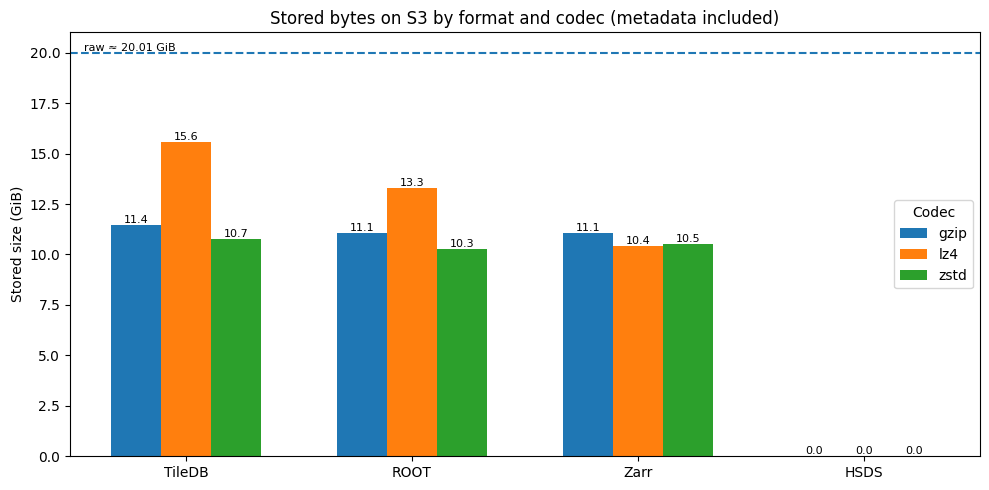

In [12]:
format_order = (
    df_ok.groupby("format")["stored_gib"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

codecs = ["gzip","lz4","zstd"]
bar_width = 0.22
x = np.arange(len(format_order))

plt.figure(figsize=(10, 5))
for j, codec in enumerate(codecs):
    sub = df_ok[(df_ok["codec"] == codec) & (df_ok["format"].isin(format_order))].copy()
    # Align sub rows in the chosen format order
    sub = sub.set_index("format").loc[format_order].reset_index()
    positions = x + (j - (len(codecs)-1)/2) * bar_width
    plt.bar(positions, sub["stored_gib"].values, width=bar_width, label=codec)
    # Value labels
    for xi, val in zip(positions, sub["stored_gib"].values):
        plt.text(xi, val, f"{val:.1f}", ha="center", va="bottom", fontsize=8, rotation=0)

# Raw baseline line
plt.axhline(RAW_GIB, linestyle="--")
plt.text(x[0] - 0.45, RAW_GIB, f"raw ≈ {RAW_GIB:.2f} GiB", va="bottom", fontsize=8)

plt.xticks(x, format_order)
plt.ylabel("Stored size (GiB)")
plt.title("Stored bytes on S3 by format and codec (metadata included)")
plt.legend(title="Codec")
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
fig_a_pdf = f"figures/fig_stored_bytes_{ts}.pdf"
fig_a_png = f"figures/fig_stored_bytes_{ts}.png"
plt.savefig(fig_a_pdf, bbox_inches="tight")
plt.savefig(fig_a_png, dpi=300, bbox_inches="tight")
print(f"Saved {fig_a_pdf} and {fig_a_png}")

## Figure: Compression ratios vs raw baseline (R = raw / stored)

Saved figures/fig_compression_ratios_20251005-124133.pdf and figures/fig_compression_ratios_20251005-124133.png


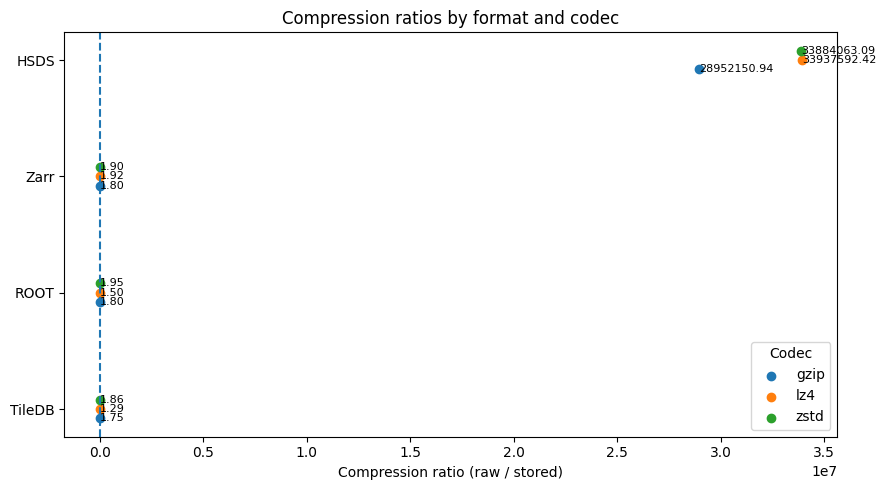

In [13]:
formats_sorted = format_order
y_base = np.arange(len(formats_sorted))

# Build plotting vectors in the chosen order
plot_rows = []
for i, fmt in enumerate(formats_sorted):
    for j, codec in enumerate(codecs):
        r = df_ok[(df_ok["format"] == fmt) & (df_ok["codec"] == codec)]
        if len(r) == 1:
            plot_rows.append({
                "format": fmt,
                "codec": codec,
                "y": i + (j - (len(codecs)-1)/2) * 0.08,  # small vertical offset by codec
                "ratio": float(r["compression_ratio"].values[0]),
            })

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(9, 5))
for codec in codecs:
    rr = plot_df[plot_df["codec"] == codec]
    plt.scatter(rr["ratio"].values, rr["y"].values, label=codec)
    # labels
    for xv, yv in zip(rr["ratio"].values, rr["y"].values):
        plt.text(xv, yv, f"{xv:.2f}", va="center", ha="left", fontsize=8)

plt.axvline(1.0, linestyle="--")
plt.yticks(y_base, formats_sorted)
plt.xlabel("Compression ratio (raw / stored)")
plt.title("Compression ratios by format and codec")
plt.legend(title="Codec", loc="lower right")
plt.tight_layout()

fig_b_pdf = f"figures/fig_compression_ratios_{ts}.pdf"
fig_b_png = f"figures/fig_compression_ratios_{ts}.png"
plt.savefig(fig_b_pdf, bbox_inches="tight")
plt.savefig(fig_b_png, dpi=300, bbox_inches="tight")
print(f"Saved {fig_b_pdf} and {fig_b_png}")

In [14]:
obj_tbl = (
    df_ok[["format","codec","object_count","stored_gib"]]
    .sort_values(["format","codec"])
    .reset_index(drop=True)
)
display(obj_tbl)

,format,codec,object_count,stored_gib
0,HSDS,gzip,2,6.910414e-07
1,HSDS,lz4,2,5.895272e-07
2,HSDS,zstd,2,5.904585e-07
3,ROOT,gzip,1,1.108758e+01
4,ROOT,lz4,1,1.330985e+01
5,ROOT,zstd,1,1.026083e+01
6,TileDB,gzip,244,1.144490e+01
7,TileDB,lz4,244,1.556152e+01
8,TileDB,zstd,244,1.074247e+01
9,Zarr,gzip,1297,1.108707e+01


## HSDS adjustment: compute stored bytes from shared `db/` by dataset UUID

In [15]:
import re
import pandas as pd
import boto3
import h5pyd
import datetime
import os
import numpy as np

BUCKET = os.getenv("BUCKET_NAME", "scatterin-thesis")
REGION = os.getenv("AWS_REGION", "eu-north-1")
HS_ENDPOINT = os.getenv("HS_ENDPOINT", "http://localhost:5101")
HS_USERNAME = os.getenv("HS_USERNAME", "test_user1")
HS_PASSWORD = os.getenv("HS_PASSWORD", "test")
HSDS_DB_PREFIX = os.getenv("HSDS_DB_PREFIX", "db/")  # typical HSDS layout root

s3 = boto3.client("s3", region_name=REGION)

HSDS_DOMAINS = {
    "gzip": "/hdf5/gzip/all_data.h5",
    "lz4":  "/hdf5/lz4/all_data.h5",
    "zstd": "/hdf5/zstd/all_data.h5",
}

def _dataset_uuid_from_hsds(domain_path: str) -> str:
    with h5pyd.File(domain_path, "r", endpoint=HS_ENDPOINT,
                    username=HS_USERNAME, password=HS_PASSWORD) as f:
        dset = f["/data"]
        # h5pyd exposes UUID on the id object; try common slots
        cand = None
        for attr in ("id", "uuid"):
            try:
                cand = getattr(dset.id, attr)
                if cand:
                    break
            except Exception:
                pass
        if isinstance(cand, bytes):
            cand = cand.decode()
        if cand is None:
            # last resort: stringifying id
            cand = str(dset.id)
        # extract uuid-looking token
        m = re.search(r"[0-9a-fA-F\-]{32,36}", str(cand))
        if not m:
            raise RuntimeError(f"Could not extract dataset UUID for {domain_path} from {cand!r}")
        return m.group(0)

def _index_s3_db(bucket: str, prefix: str) -> pd.DataFrame:
    rows = []
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            rows.append({"key": obj["Key"], "size": int(obj["Size"])})
    return pd.DataFrame(rows)

# 1) Get dataset UUIDs per codec
hsds_uuid = {codec: _dataset_uuid_from_hsds(path) for codec, path in HSDS_DOMAINS.items()}
hsds_uuid

{'gzip': 'd-d7ac06a0-29ec1eac-0fc2-f41868-cc38',
 'lz4': 'd-aded44cc-bc279dda-c927-0b33c5-217c',
 'zstd': 'd-240d0ac2-ca1de646-6f99-2b029e-a02e'}

## Build a one-time index of `db/` and map bytes to each HSDS dataset

In [18]:
db_df = _index_s3_db(BUCKET, HSDS_DB_PREFIX)
print(f"Indexed {len(db_df)} objects under {HSDS_DB_PREFIX}")

def _sum_bytes_for_uuid(df: pd.DataFrame, uuid: str) -> tuple[int, int]:
    # Match if UUID appears anywhere in key (covers c-{uuid}_..., d-{uuid}, hashed fanout paths that include UUID)
    mask = df["key"].str.contains(uuid, regex=False)
    sub = df[mask]
    return int(sub["size"].sum()), int(len(sub))

hsds_rows = []
for codec, uuid in hsds_uuid.items():
    uuid = uuid.split("-")[1]
    total_bytes, obj_count = _sum_bytes_for_uuid(db_df, uuid)
    hsds_rows.append({
        "format": "HSDS",
        "codec": codec,
        "prefix": f"{HSDS_DB_PREFIX}…(uuid:{uuid[:8]})",
        "stored_bytes": total_bytes,
        "stored_gib": total_bytes / (2**30) if total_bytes else np.nan,
        "object_count": obj_count,
        "status": "ok" if total_bytes > 0 else "missing",
    })

df_hsds_sizes = pd.DataFrame(hsds_rows).sort_values(["codec"]).reset_index(drop=True)
df_hsds_sizes.to_dict(orient="records")

Indexed 15554 objects under db/


[{'format': 'HSDS',
  'codec': 'gzip',
  'prefix': 'db/…(uuid:d7ac06a0)',
  'stored_bytes': 11929956407,
  'stored_gib': 11.110637716017663,
  'object_count': 5183,
  'status': 'ok'},
 {'format': 'HSDS',
  'codec': 'lz4',
  'prefix': 'db/…(uuid:aded44cc)',
  'stored_bytes': 20582420749,
  'stored_gib': 19.168873083777726,
  'object_count': 5183,
  'status': 'ok'},
 {'format': 'HSDS',
  'codec': 'zstd',
  'prefix': 'db/…(uuid:240d0ac2)',
  'stored_bytes': 11455701092,
  'stored_gib': 10.668953035026789,
  'object_count': 5183,
  'status': 'ok'}]

In [19]:
if "df_sizes" not in globals():
    raise RuntimeError("df_sizes not found. Run the §5.3.1 data assembly cell first.")

df_wo_hsds = df_sizes[df_sizes["format"] != "HSDS"].copy()
df_sizes_fixed = (
    pd.concat([df_wo_hsds, df_hsds_sizes], ignore_index=True)
    .sort_values(["format","codec"])
    .reset_index(drop=True)
)

# Recompute compression ratios using existing RAW_BYTES from earlier cell
if "RAW_BYTES" not in globals():
    raise RuntimeError("RAW_BYTES not found. Run the baseline derivation cell first.")

df_sizes_fixed["compression_ratio"] = np.where(
    df_sizes_fixed["stored_bytes"] > 0,
    RAW_BYTES / df_sizes_fixed["stored_bytes"],
    np.nan
)

ts = datetime.datetime.utcnow().strftime("%Y%m%d-%H%M%S")
os.makedirs("outputs", exist_ok=True)
out_csv = f"outputs/compression_sizes_with_hsds_{ts}.csv"
df_sizes_fixed.to_csv(out_csv, index=False)
print(f"Wrote {out_csv}")

# Compact manuscript table
display(
    df_sizes_fixed[["format","codec","stored_gib","object_count","compression_ratio"]]
      .round({"stored_gib":2, "compression_ratio":2})
      .sort_values(["format","codec"])
)

Wrote outputs/compression_sizes_with_hsds_20251005-124727.csv


/tmp/ipykernel_7181/1546547941.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.datetime.utcnow().strftime("%Y%m%d-%H%M%S")


,format,codec,stored_gib,object_count,compression_ratio
0,HSDS,gzip,11.11,5183,1.80
1,HSDS,lz4,19.17,5183,1.04
2,HSDS,zstd,10.67,5183,1.88
3,ROOT,gzip,11.09,1,1.80
4,ROOT,lz4,13.31,1,1.50
5,ROOT,zstd,10.26,1,1.95
6,TileDB,gzip,11.44,244,1.75
7,TileDB,lz4,15.56,244,1.29
8,TileDB,zstd,10.74,244,1.86
9,Zarr,gzip,11.09,1297,1.80


/tmp/ipykernel_7181/3684837252.py:35: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.datetime.utcnow().strftime("%Y%m%d-%H%M%S")


Saved figures/fig_stored_bytes_20251005-124943.pdf and figures/fig_stored_bytes_20251005-124943.png


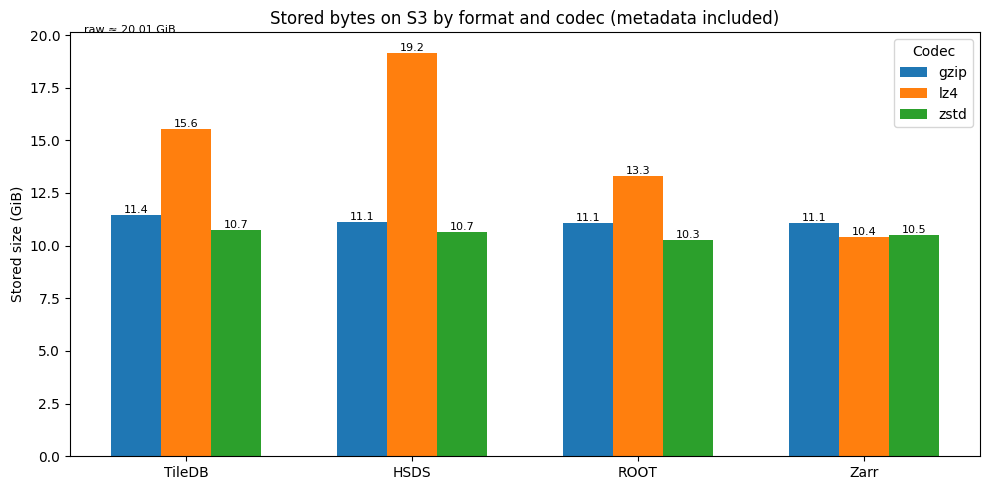

In [25]:
df_ok = df_sizes_fixed[df_sizes_fixed["status"] == "ok"].copy()

# Order formats by median stored_gib across codecs, descending
format_order = (
    df_ok.groupby("format")["stored_gib"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

codecs = ["gzip","lz4","zstd"]
bar_width = 0.22
x = np.arange(len(format_order))

plt.figure(figsize=(10, 5))
for j, codec in enumerate(codecs):
    sub = df_ok[(df_ok["codec"] == codec) & (df_ok["format"].isin(format_order))].copy()
    sub = sub.set_index("format").loc[format_order].reset_index()
    positions = x + (j - (len(codecs)-1)/2) * bar_width
    plt.bar(positions, sub["stored_gib"].values, width=bar_width, label=codec)
    for xi, val in zip(positions, sub["stored_gib"].values):
        if np.isfinite(val):
            plt.text(xi, val, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

plt.text(x[0] - 0.45, RAW_GIB, f"raw ≈ {RAW_GIB:.2f} GiB", va="bottom", fontsize=8)

plt.xticks(x, format_order)
plt.ylabel("Stored size (GiB)")
plt.title("Stored bytes on S3 by format and codec (metadata included)")
plt.legend(title="Codec")
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
ts = datetime.datetime.utcnow().strftime("%Y%m%d-%H%M%S")
fig_a_pdf = f"figures/fig_stored_bytes_{ts}.pdf"
fig_a_png = f"figures/fig_stored_bytes_{ts}.png"
plt.savefig(fig_a_pdf, bbox_inches="tight")
plt.savefig(fig_a_png, dpi=300, bbox_inches="tight")
print(f"Saved {fig_a_pdf} and {fig_a_png}")

Saved figures/fig_compression_ratios_20251005-124907.pdf and figures/fig_compression_ratios_20251005-124907.png


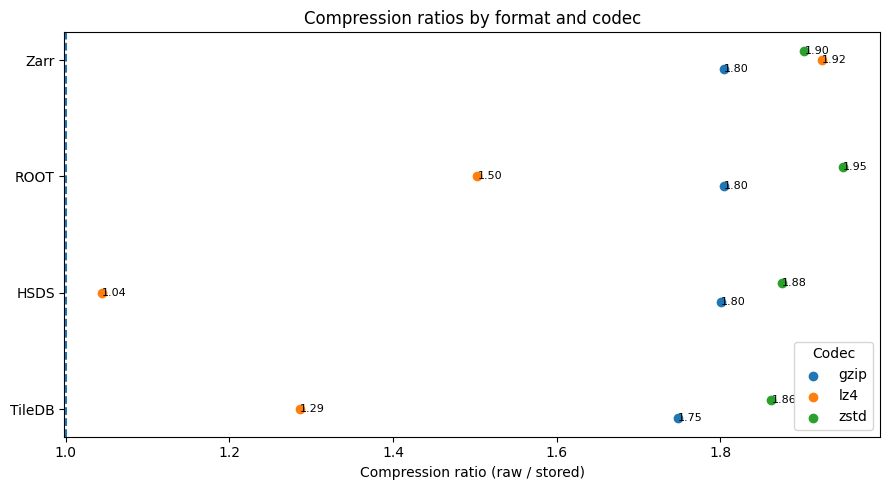

In [23]:
formats_sorted = format_order
y_base = np.arange(len(formats_sorted))

plot_rows = []
for i, fmt in enumerate(formats_sorted):
    for j, codec in enumerate(codecs):
        r = df_ok[(df_ok["format"] == fmt) & (df_ok["codec"] == codec)]
        if len(r) == 1 and np.isfinite(r["compression_ratio"].values[0]):
            plot_rows.append({
                "format": fmt,
                "codec": codec,
                "y": i + (j - (len(codecs)-1)/2) * 0.08,
                "ratio": float(r["compression_ratio"].values[0]),
            })

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(9, 5))
for codec in codecs:
    rr = plot_df[plot_df["codec"] == codec]
    plt.scatter(rr["ratio"].values, rr["y"].values, label=codec)
    for xv, yv in zip(rr["ratio"].values, rr["y"].values):
        plt.text(xv, yv, f"{xv:.2f}", va="center", ha="left", fontsize=8)

plt.axvline(1.0, linestyle="--")
plt.yticks(y_base, formats_sorted)
plt.xlabel("Compression ratio (raw / stored)")
plt.title("Compression ratios by format and codec")
plt.legend(title="Codec", loc="lower right")
plt.tight_layout()

fig_b_pdf = f"figures/fig_compression_ratios_{ts}.pdf"
fig_b_png = f"figures/fig_compression_ratios_{ts}.png"
plt.savefig(fig_b_pdf, bbox_inches="tight")
plt.savefig(fig_b_png, dpi=300, bbox_inches="tight")
print(f"Saved {fig_b_pdf} and {fig_b_png}")